# Task 1 – Convolutional–recurrent classification (WikiArt)

**GSoC / HumanAI — discussion notebook.** Here I implement **multi-task** prediction of **style**, **artist**, and **genre** on the ArtGAN **WikiArt Refined** setup: a **convolutional trunk** (ResNet-18) on **horizontal image strips**, aggregated by a **bidirectional GRU**, with **three linear heads**.

I designed this to **train on resource-constrained hardware** (consumer GPU or CPU-class laptop): a **small pretrained CNN**, **frozen backbone** by default, **subsampled data** (`MAX_SAMPLES`), and **short training** (`EPOCHS = 5`). The sections below spell out **my strategy**, **why I chose these models under that constraint**, **their strengths and weaknesses**, and **how I read the evaluation metrics** after I run training.

**Data:** paths point to `DATA_ROOT` / `CSV_ROOT`; large assets are gitignored.


## Data layout

- **Images** live under `DATA_ROOT` (WikiArt-style folders via `filepath` in metadata).
- **ArtGAN CSVs** under `CSV_ROOT`; **`metadata.csv`** at `METADATA_CSV` with `filepath`, `style`, `artist`, `genre` (and optional `split`).

The merged metadata can be **~16k+** rows. I default to **`MAX_SAMPLES = 5000`** (~4k train / ~1k val after stratified split) so **epoch time, RAM, and disk I/O** stay manageable on **one machine without a large GPU**. If I set `MAX_SAMPLES = None` I use the full table when I have the compute—runs get **longer** and **memory** goes up.


In [1]:
# Imports and configuration

import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm


def set_seed(seed: int = 42) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


set_seed(42)

DATA_ROOT = Path("data/task1_data/wikiart")
CSV_ROOT = Path("data/task1_data/wikiart_csv")
METADATA_CSV = CSV_ROOT / "metadata.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

IMG_SIZE = 224
PATCH_SPLITS = 4
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 5
LEARNING_RATE = 1e-4

LABEL_COLS = ["style", "artist", "genre"]



Using device: cuda


## Approach and overall strategy (GSoC discussion)

**How I frame the problem:** Paintings are **high-dimensional** and labels are **hierarchical / correlated** (artist ↔ style ↔ genre). I use **one shared visual representation** for **three classification tasks** so overhead stays modest compared with training three separate models.

**My strategy:**
1. **Strip-based encoding:** I resize each image to `224×224`, split it into **4 horizontal bands**, and run each band through the **same** ResNet-18 trunk. That gives me a **short sequence** of feature vectors per painting.
2. **Temporal pooling:** A **bidirectional GRU** reads that sequence; I take the **last hidden state** to summarize vertical structure (sky → ground, etc.) without a full 2D attention model.
3. **Multi-task heads:** Three linear classifiers predict style, artist, and genre from that summary.

**Why resource limits drove my choices:** Training a **large ViT** or **unfrozen ResNet-50+** on full WikiArt would need **more VRAM, longer epochs, and stronger regularization** than I budgeted for. I **freeze ImageNet-pretrained ResNet-18** and only train **GRU + heads**, which **shrinks optimizer state and backward cost** a lot—appropriate for **my laptop / ~6–8 GB GPU** and **quick iteration**. Strip + GRU is **lighter than a two-stage detector or transformer** while still satisfying the **convolutional + recurrent** requirement.


In [2]:
# Dataset

class WikiArtSequenceDataset(Dataset):
    """Horizontal strips per image; backbone + RNN consume the sequence."""

    def __init__(
        self,
        df: pd.DataFrame,
        img_root: Path,
        transform: transforms.Compose,
        label_cols: List[str],
    ) -> None:
        self.df = df.reset_index(drop=True)
        self.img_root = Path(img_root)
        self.transform = transform
        self.label_cols = label_cols

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self.img_root / row["filepath"]
        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)
        c, h, w = image.shape
        strip_h = h // PATCH_SPLITS

        strips = []
        for i in range(PATCH_SPLITS):
            start = i * strip_h
            end = h if i == PATCH_SPLITS - 1 else (i + 1) * strip_h
            strips.append(image[:, start:end, :])
        strips = torch.stack(strips, dim=0)  # (T, C, H_strip, W)

        labels = torch.tensor(row[self.label_cols].values.astype(np.int64))

        return strips, labels


# Basic transforms; you can enrich augmentations if desired
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


## Strip representation and recurrent module — trade-offs

**Strengths I get from this design:** Four strips add a **minimal notion of spatial layout** (top vs bottom of the canvas) while **reusing one CNN** per strip—cheap compared with pyramids or sliding windows. The GRU **combines** strip features with **few parameters** at sequence length 4.

**Weaknesses I accept:** **Horizontal** slicing under-models **left–right** structure, and resize loses **fine local detail**. **Artist** identity often depends on **brushwork and micro-texture** that 224px and strip pooling blur. **GRU vs LSTM** barely matters at `T=4`; either is mainly a **small trainable mixer** on frozen CNN features.

**What I would try with more resources:** Higher resolution, **learned 2D pooling**, or **partial backbone unfreezing** first—not necessarily a deeper RNN.


In [3]:
# Optional helper: build metadata.csv from official ArtGAN WikiArt CSVs

from pathlib import Path
import pandas as pd


def _load_task_df(csv_dir: Path, task_name: str) -> pd.DataFrame:
    """Load STYLE/ARTIST/GENRE CSVs and map class indices to label names.

    This version assumes a flat folder structure like:
      csv_dir/
        style_class.txt, style_train.csv, style_val.csv
        artist_class.txt, artist_train.csv, artist_val.csv
        genre_class.txt, genre_train.csv, genre_val.csv

    Each *_train/val.csv row contains: (path/to/image.jpg, class_index)
    and *_class.txt contains lines of the form: "index label_name".
    """
    task_lower = task_name.lower()   # e.g. "style"

    class_file = csv_dir / f"{task_lower}_class.txt"
    train_csv = csv_dir / f"{task_lower}_train.csv"
    val_csv = csv_dir / f"{task_lower}_val.csv"

    # class_file: "index label" per line
    classes = pd.read_csv(class_file, sep=" ", header=None, names=["class_idx", "label"])
    idx_to_label = dict(zip(classes["class_idx"], classes["label"]))

    def _load_split(csv_path: Path, split_name: str) -> pd.DataFrame:
        df = pd.read_csv(csv_path, header=None, names=["filepath", "class_idx"])
        df[task_name] = df["class_idx"].map(idx_to_label)
        df["split"] = split_name
        return df[["filepath", task_name, "split"]]

    train_df = _load_split(train_csv, "train")
    val_df = _load_split(val_csv, "val")
    return pd.concat([train_df, val_df], ignore_index=True)


def build_metadata_from_artgan_structure(
    csv_dir: Path = CSV_ROOT,
    output_csv: Path = METADATA_CSV,
) -> pd.DataFrame:
    """Create a consolidated metadata.csv with filepath, style, artist, genre.

    - Uses STYLE/ARTIST/GENRE CSVs provided with the refined WikiArt dataset
      stored under `csv_dir`.
    - Merges on `filepath` and keeps only images that appear in all three tasks.
    - Uses the split (train/val) from the style task for the final `split` column.
    """
    style_df = _load_task_df(csv_dir, "style")
    artist_df = _load_task_df(csv_dir, "artist")
    genre_df = _load_task_df(csv_dir, "genre")

    df = style_df.merge(artist_df[["filepath", "artist"]], on="filepath", how="inner")
    df = df.merge(genre_df[["filepath", "genre"]], on="filepath", how="inner")

    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv, index=False)
    print(f"Saved consolidated metadata with {len(df)} rows to {output_csv}")
    return df


# Run this only once after downloading the CSVs into CSV_ROOT to create metadata.csv for subset of data:
# consolidated_df = build_metadata_from_artgan_structure(CSV_ROOT, METADATA_CSV)
# display(consolidated_df.head())


In [4]:
# Metadata loading and label encoding


def load_metadata(metadata_csv: Path) -> pd.DataFrame:
    """Load metadata and ensure required columns exist.

    Expected columns:
    - filepath: path to image file relative to DATA_ROOT
    - style, artist, genre: string labels

    You can adapt this function if your CSV uses different names.
    """
    df = pd.read_csv(metadata_csv)
    required = {"filepath", "style", "artist", "genre"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing columns in metadata: {missing}")
    return df


def encode_labels(df: pd.DataFrame, label_cols: List[str]) -> Tuple[pd.DataFrame, Dict[str, LabelEncoder]]:
    """Encode string labels into integer IDs and return fitted encoders."""
    encoders: Dict[str, LabelEncoder] = {}
    df = df.copy()
    for col in label_cols:
        enc = LabelEncoder()
        df[col + "_id"] = enc.fit_transform(df[col].astype(str))
        encoders[col] = enc
    return df, encoders


# Load and prepare splits
raw_df = load_metadata(METADATA_CSV)
encoded_df, label_encoders = encode_labels(raw_df, LABEL_COLS)

# Use style label for stratification as a reasonable compromise
train_df, val_df = train_test_split(
    encoded_df,
    test_size=0.2,
    stratify=encoded_df["style_id"],
    random_state=42,
)

label_cols_id = [c + "_id" for c in LABEL_COLS]

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


Train samples: 13000
Val samples: 3250


In [5]:
MAX_SAMPLES = 5000  # None = use all merged rows

if MAX_SAMPLES is not None and len(encoded_df) > MAX_SAMPLES:
    encoded_df_small = (
        encoded_df.sample(n=MAX_SAMPLES, random_state=42)
        .reset_index(drop=True)
    )
    print(f"Sub-sampled to {len(encoded_df_small)} images for faster experimentation.")
else:
    encoded_df_small = encoded_df.copy()
    print(f"Using full dataset with {len(encoded_df_small)} images.")

train_df, val_df = train_test_split(
    encoded_df_small,
    test_size=0.2,
    stratify=encoded_df_small["style_id"],
    random_state=42,
)

label_cols_id = [c + "_id" for c in LABEL_COLS]

print("Train samples (after sub-sampling):", len(train_df))
print("Val samples (after sub-sampling):", len(val_df))


Sub-sampled to 5000 images for faster experimentation.
Train samples (after sub-sampling): 4000
Val samples (after sub-sampling): 1000


## Subsampling (`MAX_SAMPLES`) — why it matters for metrics

**Why I cap samples:** Random **5k-row subsampling** keeps **epoch time predictable** and stops **memory thrash** when images load from disk inside the notebook. It is an explicit **compute–variance trade-off** I document.

**Effect on evaluation:** Rare **artists** and **styles** get **fewer training examples** after sampling, which usually **hurts macro-averaged F1** and **artist accuracy** more than genre. **Weighted** metrics (in `classification_report`) stay closer to “headline” accuracy on **frequent** classes.

**What I state in my submission:** My scores are measured under **these resource limits**; **raising `MAX_SAMPLES`**, **epochs**, or **unfreezing the backbone** is the expected path to higher numbers—not a separate algorithmic trick.


In [6]:
# Dataloaders

train_dataset = WikiArtSequenceDataset(
    df=train_df,
    img_root=DATA_ROOT,
    transform=train_transform,
    label_cols=label_cols_id,
)

val_dataset = WikiArtSequenceDataset(
    df=val_df,
    img_root=DATA_ROOT,
    transform=val_transform,
    label_cols=label_cols_id,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


## Dataloaders, stratification, and laptop-friendly I/O

**Stratified split on `style_id`:** I mirror **style** proportions between train and val so **style metrics** are less biased by a skewed held-out set.

**`NUM_WORKERS = 0` and `pin_memory=False`:** I set this to reduce **multiprocessing pain** in Jupyter on Windows/macOS/Linux laptops and to **skip pinning** when CUDA is absent or tight. On a **dedicated CUDA server** I would raise `NUM_WORKERS` and set `pin_memory=True` for faster loading.

**Batch size 16:** My compromise for **GPU memory**; I would lower it if I OOM and raise it if I have headroom.


In [7]:
# Model

class ConvBackbone(nn.Module):

    def __init__(self, train_backbone: bool = False) -> None:
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.out_dim = backbone.fc.in_features

        if not train_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)
        return feats


class ConvRNNMultiTaskModel(nn.Module):
    """Strip CNN features -> GRU -> three classifiers."""

    def __init__(
        self,
        backbone: ConvBackbone,
        hidden_size: int,
        num_layers: int,
        num_classes_style: int,
        num_classes_artist: int,
        num_classes_genre: int,
    ) -> None:
        super().__init__()
        self.backbone = backbone

        self.rnn = nn.GRU(
            input_size=backbone.out_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )

        rnn_out_dim = 2 * hidden_size
        self.head_style = nn.Linear(rnn_out_dim, num_classes_style)
        self.head_artist = nn.Linear(rnn_out_dim, num_classes_artist)
        self.head_genre = nn.Linear(rnn_out_dim, num_classes_genre)

    def forward(self, x_seq: torch.Tensor):
        # x_seq: (B, T, C, H, W)
        b, t, c, h, w = x_seq.shape
        x_flat = x_seq.view(b * t, c, h, w)
        feats = self.backbone(x_flat)  # (B*T, D)
        feats = feats.view(b, t, -1)   # (B, T, D)

        rnn_out, _ = self.rnn(feats)   # (B, T, 2H)
        last = rnn_out[:, -1, :]       # (B, 2H)

        logits_style = self.head_style(last)
        logits_artist = self.head_artist(last)
        logits_genre = self.head_genre(last)

        return logits_style, logits_artist, logits_genre


## Model choice: ResNet-18 + GRU — strengths and weaknesses

**ResNet-18 (ImageNet, frozen):**
- **Strengths:** **Small** (~11M params in the full model; I only train GRU+heads), **mature** pretrained features, **fast** forward pass, **stable** optimization.
- **Weaknesses:** Features are **not art-specific**; a **frozen** trunk cannot fix **domain shift** (paintings vs natural images). **Capacity** may be too small for **hundreds of artist identities**.

**Bidirectional GRU (hidden 256, 1 layer):**
- **Strengths:** **Low parameter count**; enough to **fuse** four strip embeddings.
- **Weaknesses:** **Limited expressivity** vs cross-attention or learned per-strip weighting; **last-step** readout may drop useful mid-sequence cues.

**Why I did not default to a Transformer:** At my **data and compute budget**, ViT-style models raise **memory** and **tuning surface**; I met the brief with **CNN + RNN** and stay **honest about hardware limits**.


In [8]:
# Model, losses, optimizer

num_styles = encoded_df["style_id"].nunique()
num_artists = encoded_df["artist_id"].nunique()
num_genres = encoded_df["genre_id"].nunique()

backbone = ConvBackbone(train_backbone=False)
model = ConvRNNMultiTaskModel(
    backbone=backbone,
    hidden_size=256,
    num_layers=1,
    num_classes_style=num_styles,
    num_classes_artist=num_artists,
    num_classes_genre=num_genres,
).to(DEVICE)

criterion_style = nn.CrossEntropyLoss()
criterion_artist = nn.CrossEntropyLoss()
criterion_genre = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)


## Loss, optimization, and multi-task balance

I sum **three cross-entropies** (style, artist, genre) with **equal weight**—a **simple multi-task baseline** that does **not** reweight hard tasks (artist) vs easy ones (genre). **What I usually see:** genre is **easiest**, artist **hardest**—if artist loss dominates numerically, **task weights** or **sampling** would be my next experiment.

**Adam at `1e-4`** on **trainable parameters only** (backbone frozen). **Unfreezing last ResNet stages** is my natural **next step** when GPU memory allows so textures can adapt to **paintings**.


In [9]:
# Train / eval

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion_style: nn.Module,
    criterion_artist: nn.Module,
    criterion_genre: nn.Module,
) -> float:
    model.train()
    total_loss = 0.0

    for x_seq, y in tqdm(loader, desc="Train", leave=False):
        x_seq = x_seq.to(DEVICE)
        y = y.to(DEVICE)
        y_style, y_artist, y_genre = y[:, 0], y[:, 1], y[:, 2]

        optimizer.zero_grad()
        logits_style, logits_artist, logits_genre = model(x_seq)

        loss_style = criterion_style(logits_style, y_style)
        loss_artist = criterion_artist(logits_artist, y_artist)
        loss_genre = criterion_genre(logits_genre, y_genre)

        loss = loss_style + loss_artist + loss_genre
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_seq.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
) -> Dict[str, np.ndarray]:
    model.eval()

    all_y = []
    all_pred_style, all_pred_artist, all_pred_genre = [], [], []

    for x_seq, y in tqdm(loader, desc="Eval", leave=False):
        x_seq = x_seq.to(DEVICE)
        y = y.to(DEVICE)

        logits_style, logits_artist, logits_genre = model(x_seq)
        pred_style = logits_style.argmax(dim=1).cpu().numpy()
        pred_artist = logits_artist.argmax(dim=1).cpu().numpy()
        pred_genre = logits_genre.argmax(dim=1).cpu().numpy()

        all_pred_style.append(pred_style)
        all_pred_artist.append(pred_artist)
        all_pred_genre.append(pred_genre)
        all_y.append(y.cpu().numpy())

    all_y = np.concatenate(all_y, axis=0)
    all_pred_style = np.concatenate(all_pred_style, axis=0)
    all_pred_artist = np.concatenate(all_pred_artist, axis=0)
    all_pred_genre = np.concatenate(all_pred_genre, axis=0)

    y_style, y_artist, y_genre = all_y[:, 0], all_y[:, 1], all_y[:, 2]

    print("Style classification report:")
    print(classification_report(y_style, all_pred_style, zero_division=0))

    print("Artist classification report:")
    print(classification_report(y_artist, all_pred_artist, zero_division=0))

    print("Genre classification report:")
    print(classification_report(y_genre, all_pred_genre, zero_division=0))

    return {
        "y_true": all_y,
        "y_pred_style": all_pred_style,
        "y_pred_artist": all_pred_artist,
        "y_pred_genre": all_pred_genre,
    }


## Training protocol and what to expect each epoch

Each epoch I run a **full training pass** then **validation** with **`classification_report`** per task. I use those reports for **per-class precision/recall/F1**, not only accuracy.

**Under my resource limits:** **`EPOCHS = 5`** is **short**; loss may still be **dropping** when I stop. In my write-up I note that **longer training** or **early stopping on val loss** would be standard if I had more time.


In [10]:
history = {"train_loss": []}

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion_style,
        criterion_artist,
        criterion_genre,
    )
    history["train_loss"].append(train_loss)
    print(f"Train loss: {train_loss:.4f}")

    _ = evaluate(model, val_loader)


Epoch 1/5


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Train loss: 6.5497


Eval:   0%|          | 0/63 [00:00<?, ?it/s]

Style classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        40
           4       0.00      0.00      0.00        23
           5       0.00      0.00      0.00        38
           6       0.00      0.00      0.00         1
           7       0.57      0.86      0.69       315
           8       0.00      0.00      0.00        42
           9       0.00      0.00      0.00        41
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00       103
          12       0.29      0.71      0.41       207
          13       1.00      0.06      0.11        68
          14       0.81      0.18      0.29        73
          15       0.00      0.00      0.00         3

    accuracy                           0.43      10

...

Style classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         3
           2       0.33      0.15      0.21        39
           3       0.58      0.38      0.45        40
           4       0.50      0.26      0.34        23
           5       0.21      0.08      0.12        38
           6       0.00      0.00      0.00         1
           7       0.65      0.90      0.75       315
           8       0.79      0.36      0.49        42
           9       0.65      0.32      0.43        41
          10       0.00      0.00      0.00         3
          11       0.38      0.21      0.27       103
          12       0.51      0.63      0.56       207
          13       0.79      0.66      0.72        68
          14       0.69      0.75      0.72        73
          15       0.00      0.00      0.00         3

    accuracy                           0.59      10

Train:   0%|          | 0/250 [00:00<?, ?it/s]

Train loss: 3.8018


Eval:   0%|          | 0/63 [00:00<?, ?it/s]

Style classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         3
           2       0.47      0.21      0.29        39
           3       0.71      0.42      0.53        40
           4       0.53      0.39      0.45        23
           5       0.25      0.08      0.12        38
           6       0.00      0.00      0.00         1
           7       0.73      0.86      0.79       315
           8       0.56      0.45      0.50        42
           9       0.58      0.61      0.60        41
          10       0.00      0.00      0.00         3
          11       0.45      0.50      0.47       103
          12       0.59      0.64      0.62       207
          13       0.73      0.75      0.74        68
          14       0.75      0.75      0.75        73
          15       0.00      0.00      0.00         3

    accuracy                           0.64      10

## Epoch budget and scaling up

**`EPOCHS = 5`** keeps the notebook **runnable end-to-end** while I develop. **Validation loss** may not have plateaued.

**If I scale compute:** I would increase **epochs**, **`MAX_SAMPLES`**, optionally **unfreeze** part of ResNet-18, add **stronger augmentations**, or use **mixed precision** on GPU. Each step targets **higher accuracy/F1** without changing the architecture.


## Outlier analysis — qualitative evaluation beyond averages

High **per-sample validation loss** (sum of CE over the three tasks) flags **hard examples** for me: possible **label noise**, **ambiguous** genre/style, or **underrepresented** styles in training.

The next code cell **ranks** validation images by loss and **plots thumbnails**. I use that to **check** whether errors are **model failures** or **metadata / taxonomy**


## Reading outlier plots

I look for **atypical** works for an artist, **borderline** style boundaries, **tiny class support**, or **CSV merge** quirks. Outliers are **not** necessarily a fourth metric for me; they help along with **precision/recall/F1**.


Outlier loss:   0%|          | 0/63 [00:00<?, ?it/s]

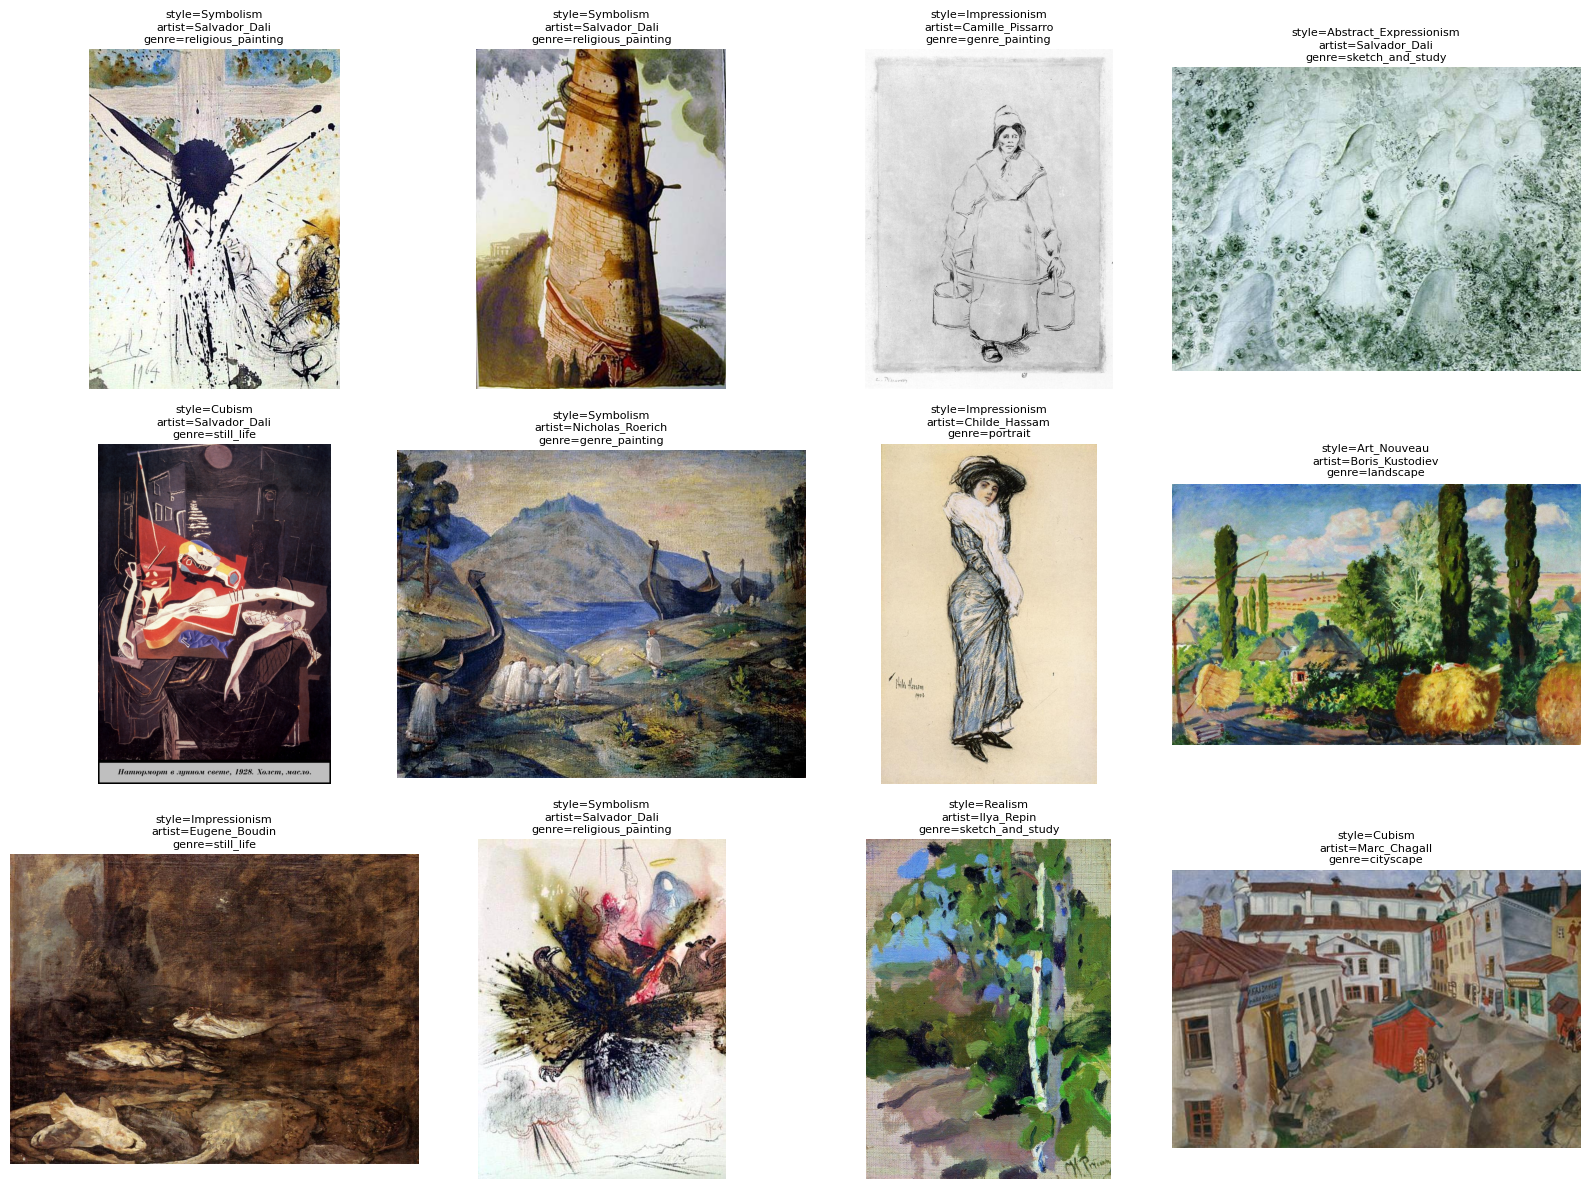

In [15]:
# Outliers

@torch.no_grad()
def compute_per_sample_loss(
    model: nn.Module,
    loader: DataLoader,
    criterion_style: nn.Module,
    criterion_artist: nn.Module,
    criterion_genre: nn.Module,
) -> np.ndarray:
    model.eval()
    losses = []

    ce_style = nn.CrossEntropyLoss(reduction="none")
    ce_artist = nn.CrossEntropyLoss(reduction="none")
    ce_genre = nn.CrossEntropyLoss(reduction="none")

    for x_seq, y in tqdm(loader, desc="Outlier loss", leave=False):
        x_seq = x_seq.to(DEVICE)
        y = y.to(DEVICE)
        y_style, y_artist, y_genre = y[:, 0], y[:, 1], y[:, 2]

        logits_style, logits_artist, logits_genre = model(x_seq)

        loss_style = ce_style(logits_style, y_style)
        loss_artist = ce_artist(logits_artist, y_artist)
        loss_genre = ce_genre(logits_genre, y_genre)

        loss = loss_style + loss_artist + loss_genre
        losses.append(loss.detach().cpu().numpy())

    return np.concatenate(losses, axis=0)


def visualize_top_k_outliers(
    df_val: pd.DataFrame,
    losses: np.ndarray,
    k: int = 12,
    img_root: Path = DATA_ROOT,
) -> None:
    """Show the top-k highest-loss validation images with labels."""
    assert len(df_val) == len(losses)
    indices = np.argsort(losses)[-k:][::-1]

    ncols = 4
    nrows = int(np.ceil(k / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for ax, idx in zip(axes, indices):
        row = df_val.iloc[idx]
        img_path = img_root / row["filepath"]
        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)
        title = f"style={row['style']}\nartist={row['artist']}\ngenre={row['genre']}"
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Example usage after training:
val_losses = compute_per_sample_loss(model, val_loader, criterion_style, criterion_artist, criterion_genre)
visualize_top_k_outliers(val_df, val_losses, k=12, img_root=DATA_ROOT)


## Evaluation metrics — why these, and what to look for

I use **`classification_report`** from scikit-learn for each task:

| Metric | Why it is useful | What I look for |
|--------|------------------|-----------------|
| **Accuracy** | Easy to communicate | **Misleading** with many rare artist classes; still informative for **genre** if it is balanced enough |
| **Macro precision / recall / F1** | **Equal weight per class** | Shows **tail-class** failure (common for **artist**) |
| **Weighted precision / recall / F1** | **Weighted by support** | Closer to “overall” behaviour dominated by **frequent** styles/artists |

**Typical ordering I expect:** **genre ≥ style ≥ artist** on F1 with this architecture and sampling—**artist** has **many fine-grained classes** and **high intra-class visual diversity**.

## Confusion matrices — systematic errors vs noise

Heatmaps show **which classes get confused** with which. **Style:** I look for **adjacent movements** (related schools) as **off-diagonal blocks**. **Artist:** I expect **diffuse** confusion when **many classes** have **few images**. **Genre:** often **cleaner** if categories are broad.

**Strength:** Visual proof of **structured mistakes** (better than one accuracy). **Weakness:** **Large class counts** make **artist** matrices **hard to read**.


Eval:   0%|          | 0/63 [00:00<?, ?it/s]

Style classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         3
           2       0.47      0.21      0.29        39
           3       0.71      0.42      0.53        40
           4       0.53      0.39      0.45        23
           5       0.25      0.08      0.12        38
           6       0.00      0.00      0.00         1
           7       0.73      0.86      0.79       315
           8       0.56      0.45      0.50        42
           9       0.58      0.61      0.60        41
          10       0.00      0.00      0.00         3
          11       0.45      0.50      0.47       103
          12       0.59      0.64      0.62       207
          13       0.73      0.75      0.74        68
          14       0.75      0.75      0.75        73
          15       0.00      0.00      0.00         3

    accuracy                           0.64      10

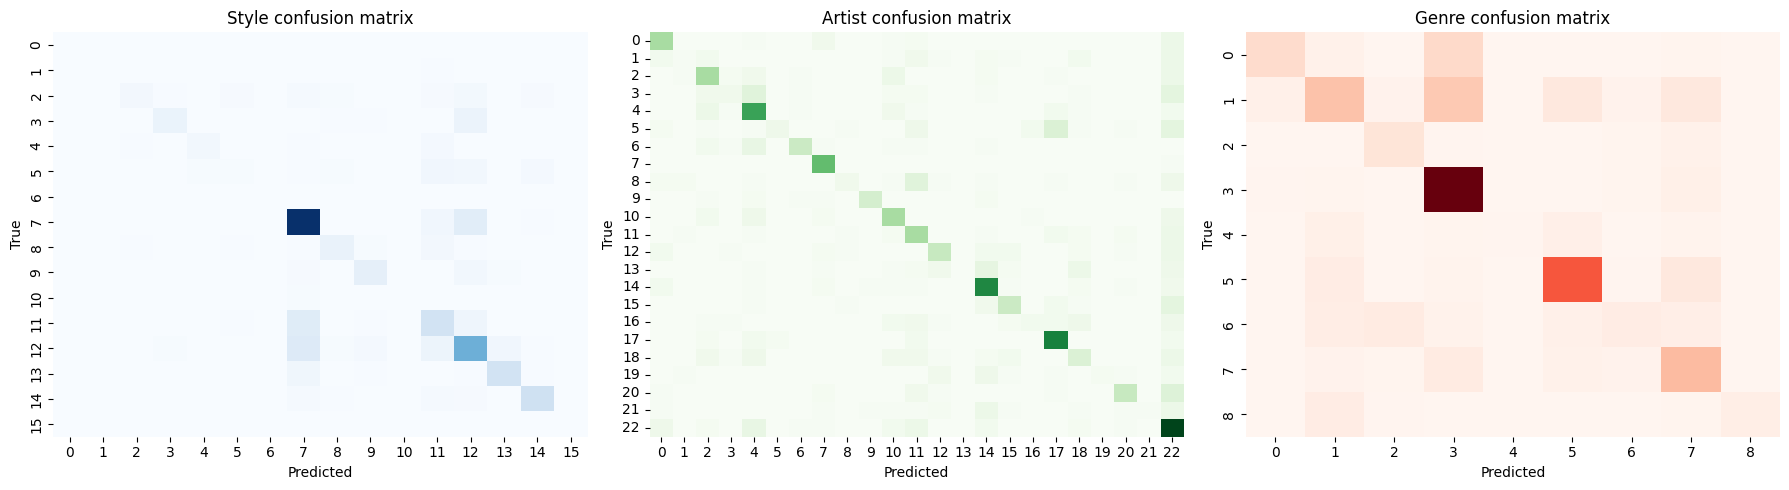

Final style accuracy: 0.641
Final artist accuracy: 0.515
Final genre accuracy: 0.623


In [16]:
# Confusion matrices

from sklearn.metrics import confusion_matrix

results = evaluate(model, val_loader)

y_true = results["y_true"]
y_style, y_artist, y_genre = y_true[:, 0], y_true[:, 1], y_true[:, 2]

cm_style = confusion_matrix(y_style, results["y_pred_style"])
cm_artist = confusion_matrix(y_artist, results["y_pred_artist"])
cm_genre = confusion_matrix(y_genre, results["y_pred_genre"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_style, ax=axes[0], cmap="Blues", cbar=False)
axes[0].set_title("Style confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_artist, ax=axes[1], cmap="Greens", cbar=False)
axes[1].set_title("Artist confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(cm_genre, ax=axes[2], cmap="Reds", cbar=False)
axes[2].set_title("Genre confusion matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

print("Final style accuracy:", (y_style == results["y_pred_style"]).mean())
print("Final artist accuracy:", (y_artist == results["y_pred_artist"]).mean())
print("Final genre accuracy:", (y_genre == results["y_pred_genre"]).mean())


## GSoC submission — Conclusion (Task 1)

**What I implemented:** Multi-task **CNN (ResNet-18 strips) + bidirectional GRU + three heads** for style, artist, and genre.

**Hardware-driven choices:** **Frozen** small backbone, **5k sample cap**, **5 epochs**, **modest batch size**, and **notebook-safe DataLoader** settings so the pipeline runs on **typical student hardware** like mine.

**Strengths:** Clear **inductive bias** (spatial strips + recurrence), **efficient training**, **interpretable** per-task reports and confusion matrices, **outlier** inspection for qualitative error analysis.

**Weaknesses:** **Generic** ImageNet features, **no** art-specific pretraining, **limited** capacity for **fine-grained artist ID**, **horizontal-biased** spatial model.

**Metrics takeaway:** I lean on **macro-F1** to discuss **rare classes**; I compare **three tasks** to show **which label type** the representation supports best; I use **confusion matrices and outliers** to argue **what I would improve next** (data, unfreezing, architecture)—not only to report one accuracy.
